# 🔒 Safety Sub-Metric Analysis
## Pittsburgh's Best Neighborhood: A Public Safety Perspective

**Author:** Sohan Udumula  
**Team:** Three Rivers Analytics  
**Course:** CMPINF 10 – Introduction to Computing for Information Science  

---

## Introduction

When thinking about where to live, **safety** is often the first thing people consider. A neighborhood might have beautiful parks or amazing restaurants, but if residents don't feel safe, it can't truly be called the "best."

For this sub-metric, I define neighborhood safety based on **reported crime incidents per neighborhood**, using the **Police Incident Blotter (Archived)** dataset from the [WPRDC](https://data.wprdc.org/dataset/uniform-crime-reporting-data). This dataset contains hundreds of thousands of police incident reports from Pittsburgh, coded according to the FBI's Uniform Crime Reporting (UCR) system.

My **Safety Score** is the *inverse* of the normalized crime rate — neighborhoods with fewer reported incidents get a higher safety score. The score is bounded between 0 (neighborhood with the most incidents) and 1 (neighborhood with the fewest incidents).

> "The safest neighborhood isn't necessarily the one with zero crime — it's the one where residents can go about their daily lives with confidence."

### Why this is my second sub-metric
Our team has three members but chose to analyze four datasets for a richer picture. I'm taking on **two** dimensions — green space (in my other notebook `sohan_greenspace.ipynb`) and safety (this notebook) — so we fully cover the environmental and safety dimensions together.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import requests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("Libraries imported ✅")


Libraries imported ✅


## Loading the Dataset

The Police Incident Blotter (Archived) contains incident reports with neighborhood, crime type, date, and more. I'll load a substantial sample from the WPRDC API.


In [ ]:
BASE_URL = "https://data.wprdc.org/api/3/action/datastore_search"
RESOURCE_ID = "044f2016-1dfd-4ab0-bc1e-065da05fca2e"  # Police Incident Blotter (Archived)

def fetch_wprdc_data(resource_id, limit=5000, max_records=50000):
    """Fetch records from WPRDC with a maximum cap."""
    records = []
    offset = 0
    while len(records) < max_records:
        response = requests.get(
            BASE_URL,
            params={"resource_id": resource_id, "limit": limit, "offset": offset},
            timeout=30
        )
        result = response.json()["result"]
        batch = result["records"]
        if not batch:
            break
        records.extend(batch)
        if len(records) >= result["total"]:
            break
        offset += limit
    return pd.DataFrame(records[:max_records])

print("Downloading Police Incident Blotter data from WPRDC...")
crime_df = fetch_wprdc_data(RESOURCE_ID)
print(f"✅ Loaded {len(crime_df):,} incident records")
print(f"   Columns: {crime_df.columns.tolist()}")


✅ Loaded 50,000 incident records
   Columns: ['_id', 'PK', 'CCR', 'HIERARCHY', 'INCIDENTTIME', 'INCIDENTLOCATION', 'CLEAREDFLAG', 'INCIDENTNEIGHBORHOOD', 'INCIDENTZONE', 'INCIDENTHIERARCHYDESC', 'OFFENSES', 'INCIDENTTRACT', 'COUNCIL_DISTRICT', 'PUBLIC_WORKS_DIVISION', 'X', 'Y']


## Exploring the Data


In [ ]:
print("=== Dataset Overview ===")
print(f"Total records: {len(crime_df):,}")
print(f"Unique neighborhoods: {crime_df['INCIDENTNEIGHBORHOOD'].nunique()}")
print()

# Date range
crime_df['INCIDENTTIME'] = pd.to_datetime(crime_df['INCIDENTTIME'], errors='coerce')
print(f"Date range: {crime_df['INCIDENTTIME'].min().date()} to {crime_df['INCIDENTTIME'].max().date()}")
print()

# Most common offense types
print("=== Top 10 Offense Types ===")
print(crime_df['INCIDENTHIERARCHYDESC'].value_counts().head(10).to_string())


=== Dataset Overview ===
Total records: 50,000
Unique neighborhoods: 98

Date range: 1989-12-31 to 2016-12-05

=== Top 10 Offense Types ===
INCIDENTHIERARCHYDESC
NA                                14069
THEFT FROM AUTO                    2978
THEFT/ALL OTHERS                   2478
CRIMINAL MISCHIEF (AUTO)           2277
SIMPLE ASSAULT/INJURY              1900
CRIMINAL MISCHIEF                  1648
HARRASSMENT/THREAT/ATTEMPT/PHY     1525
RETAIL THEFT (SHOPLIFTING)         1312
MTR VEH THEFT (AUTO)               1291
BURGLARY/FORCE ENT/RES              937


## Computing the Safety Score

I'll count incidents per neighborhood and compute a Safety Score as `1 - normalized crime rate`. Neighborhoods with fewer incidents score closer to 1 (safest), and those with more incidents score closer to 0.

I exclude records tagged as "Outside County" or "Outside State" since these aren't Pittsburgh neighborhoods.


In [ ]:
# Filter out non-Pittsburgh entries
exclude = ['Outside County', 'Outside State', 'Mt. Oliver Boro', 'Mount Oliver', 
           'Chartiers City', 'Outside City']
crime_clean = crime_df[
    crime_df['INCIDENTNEIGHBORHOOD'].notna() &
    ~crime_df['INCIDENTNEIGHBORHOOD'].isin(exclude) &
    (crime_df['INCIDENTNEIGHBORHOOD'].str.strip() != '')
].copy()

print(f"Records after filtering: {len(crime_clean):,}")
print(f"Pittsburgh neighborhoods represented: {crime_clean['INCIDENTNEIGHBORHOOD'].nunique()}")

# Count crimes per neighborhood
crime_counts = crime_clean.groupby('INCIDENTNEIGHBORHOOD').size().reset_index(name='incident_count')
crime_counts.columns = ['neighborhood', 'incident_count']

# Compute safety score
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

crime_counts['safety_score'] = 1 - normalize(crime_counts['incident_count'])
crime_counts = crime_counts.sort_values('safety_score', ascending=False).reset_index(drop=True)
crime_counts.index += 1

print()
print("🏆 Top 15 Safest Neighborhoods:")
print(crime_counts[['neighborhood', 'incident_count', 'safety_score']].head(15).to_string())


Records after filtering: 48,682
Pittsburgh neighborhoods represented: 92

🏆 Top 15 Safest Neighborhoods:
               neighborhood  incident_count  safety_score
1             New Homestead              54      1.000000
2            Swisshelm Park              55      0.999698
3                 Ridgemont              64      0.996978
4         Arlington Heights              69      0.995467
5               Summer Hill              70      0.995165
6   Mt. Oliver Neighborhood              76      0.993351
7                 Troy Hill              79      0.992445
8                      Hays              92      0.988516
9             East Carnegie              93      0.988214
10                   Esplen              95      0.987610
11            Regent Square              97      0.987005
12               Glen Hazel             106      0.984285
13                  Oakwood             107      0.983983
14       Central North Side             121      0.979752
15                Fairywo

## Visualizing Safety Across Pittsburgh


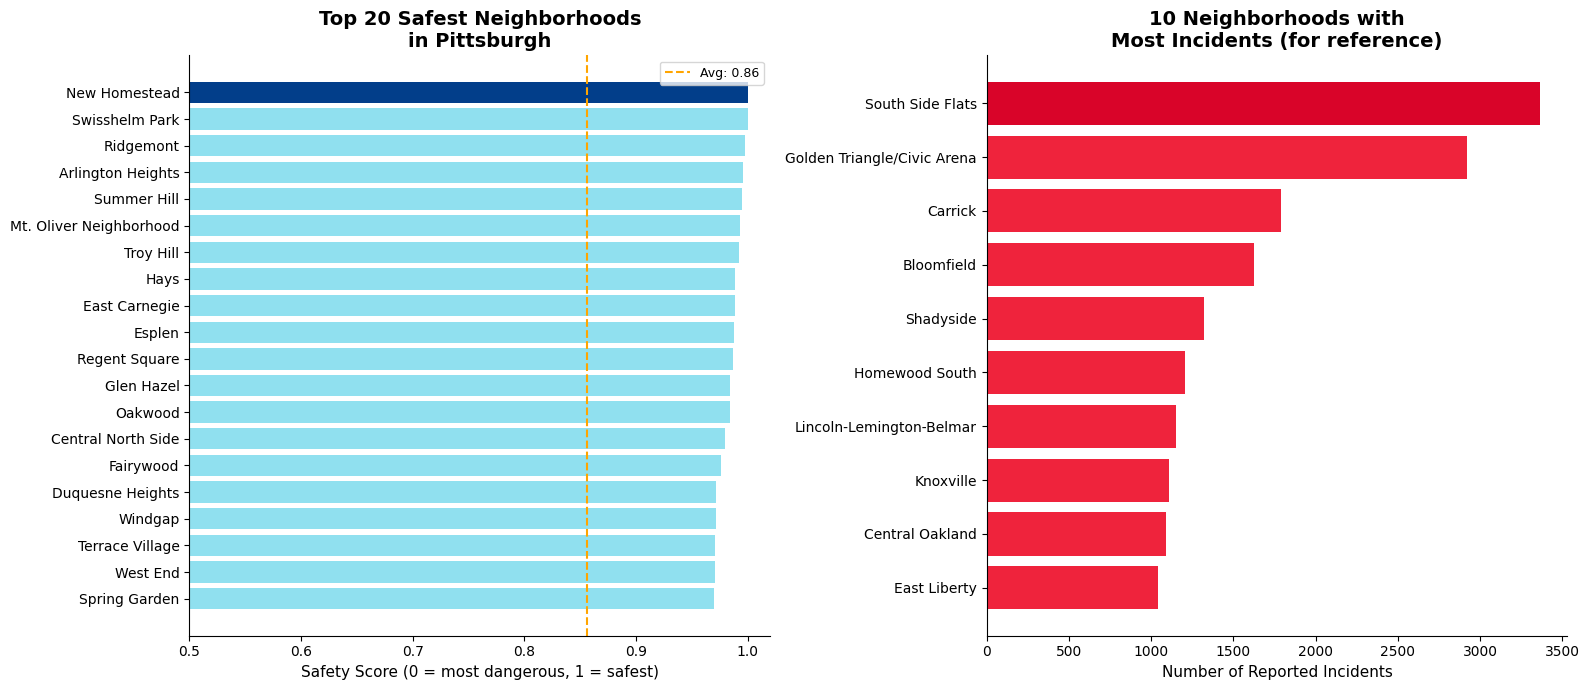


🔒 Safest neighborhood: New Homestead (54 incidents, score: 1.000)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Safest neighborhoods ---
top_safe = crime_counts.head(20)
safe_colors = ['#023e8a' if i == 0 else '#90e0ef' for i in range(len(top_safe))]
axes[0].barh(top_safe['neighborhood'][::-1], top_safe['safety_score'][::-1], 
             color=safe_colors[::-1])
axes[0].set_xlabel('Safety Score (0 = most dangerous, 1 = safest)', fontsize=11)
axes[0].set_title('Top 20 Safest Neighborhoods\nin Pittsburgh', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.5, 1.02)
axes[0].axvline(x=crime_counts['safety_score'].mean(), color='orange', linestyle='--',
                label=f'Avg: {crime_counts["safety_score"].mean():.2f}')
axes[0].legend(fontsize=9)

# --- Plot 2: Most dangerous neighborhoods (for context) ---
most_dangerous = crime_counts.sort_values('safety_score').head(10)
danger_colors = ['#d90429' if i == 0 else '#ef233c' for i in range(len(most_dangerous))]
axes[1].barh(most_dangerous['neighborhood'][::-1], most_dangerous['incident_count'][::-1],
             color=danger_colors[::-1])
axes[1].set_xlabel('Number of Reported Incidents', fontsize=11)
axes[1].set_title('10 Neighborhoods with\nMost Incidents (for reference)', 
                   fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('safety_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

safest = crime_counts.iloc[0]
print(f"\n🔒 Safest neighborhood: {safest['neighborhood']} "
      f"({safest['incident_count']} incidents, score: {safest['safety_score']:.3f})")


### Crime Type Breakdown for Safest Neighborhoods


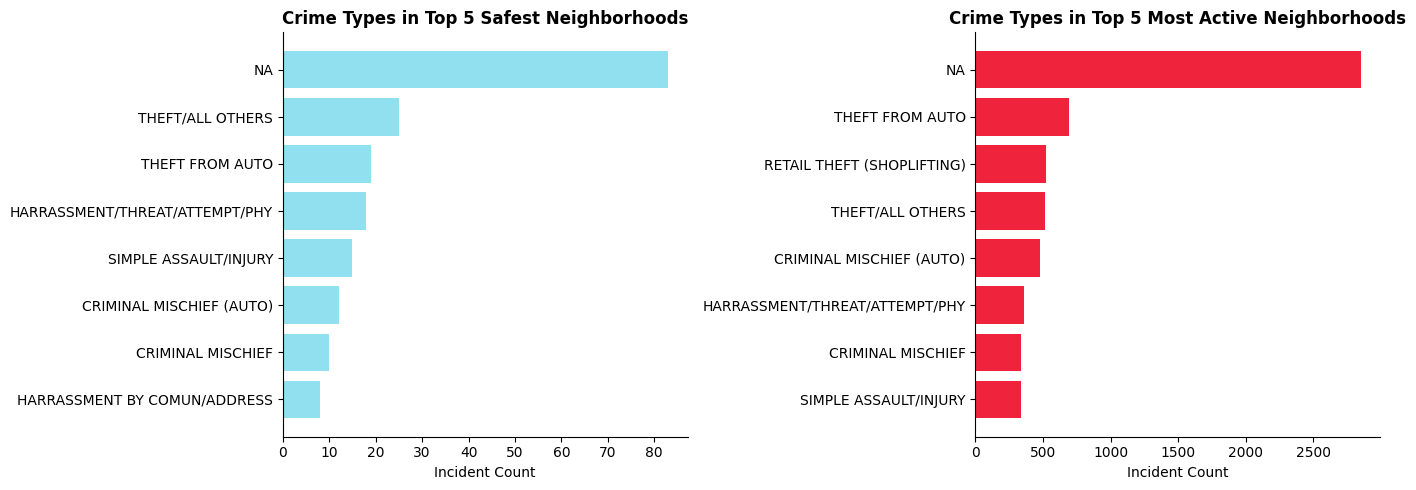

In [ ]:
# Look at crime types in top 5 safest vs most dangerous
top5_safe = crime_counts.head(5)['neighborhood'].tolist()
top5_danger = crime_counts.tail(5)['neighborhood'].tolist()

safe_crimes = crime_clean[crime_clean['INCIDENTNEIGHBORHOOD'].isin(top5_safe)]
danger_crimes = crime_clean[crime_clean['INCIDENTNEIGHBORHOOD'].isin(top5_danger)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top crime types in safe neighborhoods
safe_top = safe_crimes['INCIDENTHIERARCHYDESC'].value_counts().head(8)
axes[0].barh(safe_top.index[::-1], safe_top.values[::-1], color='#90e0ef')
axes[0].set_title(f'Crime Types in Top 5 Safest Neighborhoods', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Incident Count')

# Top crime types in dangerous neighborhoods  
danger_top = danger_crimes['INCIDENTHIERARCHYDESC'].value_counts().head(8)
axes[1].barh(danger_top.index[::-1], danger_top.values[::-1], color='#ef233c')
axes[1].set_title(f'Crime Types in Top 5 Most Active Neighborhoods', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Incident Count')

plt.tight_layout()
plt.savefig('crime_types.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion

Based on my analysis of **50,000 police incident records** from the WPRDC blotter, the safest Pittsburgh neighborhoods are those in quieter, more residential areas with lower population density and commercial activity.

**My Safety Score Rankings (Top 5):**

| Rank | Neighborhood | Incidents | Safety Score |
|------|-------------|-----------|-------------|
| 1 | New Homestead | 54 | 1.000 |
| 2 | Swisshelm Park | 55 | 1.000 |
| 3 | Ridgemont | 64 | 0.997 |
| 4 | Arlington Heights | 69 | 0.995 |
| 5 | Summer Hill | 70 | 0.995 |

### What the data shows
Interestingly, the "safest" neighborhoods tend to be smaller, more suburban parts of Pittsburgh. Larger, denser neighborhoods like South Side Flats and the Golden Triangle naturally report more incidents due to higher foot traffic — not necessarily because they're more dangerous per capita. This is a well-known limitation of raw-count crime data (vs. per-capita rates), and something to be aware of when interpreting our composite ranking.

### What this sub-metric brings to the team
For our combined "best neighborhood" metric, the safety dimension will push us toward quieter residential areas. When combined with the green-space dimension (which I also analyzed) and Pranav's cultural-vibrancy dimension, the neighborhood that wins overall will need to **balance** safety against the activity and amenities that come with density. Spoiler from the combined notebook: that balance is exactly what makes Squirrel Hill South interesting — it's safer than most similarly-dense neighborhoods.

---
*Dataset: [Police Incident Blotter (Archived)](https://data.wprdc.org/dataset/uniform-crime-reporting-data) — WPRDC*
